In [1]:
from sepsis_osc.utils.jax_config import setup_jax
setup_jax(simulation=True)
import jax.numpy as jnp
import jax.random as jr
from diffrax import Dopri5, Dopri8

from sepsis_osc.dnm.dynamic_network_model import DNMConfig, DynamicNetworkModel
from sepsis_osc.utils.config import jax_random_seed
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FFMpegWriter, FuncAnimation, PillowWriter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from sepsis_osc.dnm.dynamic_network_model import DNMState, DNMMetrics
from sepsis_osc.utils.config import plt_params

from sepsis_osc.ldm.lookup import LatentLookup, as_2d_indices
from sepsis_osc.storage.storage_interface import Storage
from sepsis_osc.visualisations.viz_param_space import pretty_plot, space_plot

plt.rcParams.update(plt_params)

In [2]:
rand_key = jr.key(jax_random_seed + 1)
M = 1
rand_keys = jr.split(rand_key, M)

#### Parameters
N = 200
conf_sync = DNMConfig(
    N=N,
    C=0.2,  # local infection
    omega_1=0.0,
    omega_2=0.0,
    a_1=1.0,
    epsilon_1=0.03,  # adaption rate
    epsilon_2=0.3,  # adaption rate
    alpha=-0.28,  # phase lage
    beta=0.5,  # age parameter
    sigma=1.0,
)
conf_cluster = DNMConfig(
    N=N,
    C=0.2,  # local infection
    omega_1=0.0,
    omega_2=0.0,
    a_1=1.0,
    epsilon_1=0.03,  # adaption rate
    epsilon_2=0.3,  # adaption rate
    alpha=-0.28,  # phase lage
    beta=0.7,  # age parameter
    sigma=1.0,
)

T_init, T_max = 0, 200
T_step = 0.5
dnm = DynamicNetworkModel(full_save=True, steady_state_check=False, full_save_dtype=jnp.float32)


In [3]:

sol_sync = dnm.integrate(
    config=conf_sync,
    M=M,
    key=rand_key,
    T_init=0,
    T_max=T_max,
    T_step=T_step,
    ts=np.arange(T_init, T_max, T_step),
    solver=Dopri8(),
)
sol_cluster = dnm.integrate(
    config=conf_cluster,
    M=M,
    key=rand_key,
    T_init=0,
    T_max=T_max,
    T_step=T_step,
    ts=np.arange(T_init, T_max, T_step),
    solver=Dopri8(),
)

ys_sync, dys_sync = sol_sync.ys
print(ys_sync.shape, dys_sync.shape)
ys_sync, dys_sync= ys_sync.remove_infs().squeeze().enforce_bounds(), dys_sync.remove_infs().squeeze()
ts_sync = np.asarray(sol_sync.ts).squeeze()
ts_sync = ts_sync[~jnp.isinf(ts_sync)]

ys_cluster, dys_cluster = sol_cluster.ys
ys_cluster, dys_cluster = ys_cluster.remove_infs().squeeze().enforce_bounds(), dys_cluster.remove_infs().squeeze()
ts_cluster = np.asarray(sol_cluster.ts).squeeze()
ts_cluster = ts_cluster[~jnp.isinf(ts_cluster)]

100.00%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| [00:00<00:00, 208.31%/s]
2026-02-26 09:38:12 - sepsis_osc.utils.utils         - INFO     - func:'integrate' took: 7.026501 sec
100.00%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| [00:00<00:00, 305.72%/s]
2026-02-26 09:38:13 - sepsis_osc.utils.utils         - INFO     - func:'integrate' took: 0.378826 sec


{'kappa_1': (401, 1, 200, 200), 'kappa_2': (401, 1, 200, 200), 'm_1': (401, 1), 'm_2': (401, 1), 'phi_1': (401, 1, 200), 'phi_2': (401, 1, 200), 'v_1': (401, 1), 'v_2': (401, 1)} {'kappa_1': (401, 1, 200, 200), 'kappa_2': (401, 1, 200, 200), 'm_1': (401, 1), 'm_2': (401, 1), 'phi_1': (401, 1, 200), 'phi_2': (401, 1, 200), 'v_1': (401, 1), 'v_2': (401, 1)}


In [25]:
def gif_both(
    ys_1: DNMState,
    dys_1: DNMState,
    ys_2: DNMState,
    dys_2: DNMState,
    ts: np.ndarray,
    *,
    fps: int = 10,
    filename: str = "figures/kuramoto.gif",
    single: int | None = None
) -> None:
    T, N = ys_1.phi_1.shape
    fig= plt.figure(figsize=(8, 4))

    # 2 rows, 5 columns → column 2 is a spacer
    gs = fig.add_gridspec(
        2, 5,
        width_ratios=[1, 1, 0.0025, 1, 1],
        wspace=0.9
    )
    axs = np.asarray([[None]*4 for _ in range(2)])
    # Top row (polar)
    axs[0,0] = fig.add_subplot(gs[0, 0], projection="polar")
    axs[0,1] = fig.add_subplot(gs[0, 1], projection="polar")
    axs[0,2] = fig.add_subplot(gs[0, 3], projection="polar")
    axs[0,3] = fig.add_subplot(gs[0, 4], projection="polar")
    
    # Bottom row (normal axes, or also polar if you want)
    axs[1,0] = fig.add_subplot(gs[1, 0])
    axs[1,1] = fig.add_subplot(gs[1, 1])
    axs[1,2] = fig.add_subplot(gs[1, 3])
    axs[1,3] = fig.add_subplot(gs[1, 4])

    radii = np.ones(N)
    N_bins = 36
    bin_edges = np.linspace(0, 2 * np.pi, N_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bottom = 0.1
    range_n = np.arange(N)

    pscatters = tuple()
    dscatters = tuple()
    bars = tuple()
    for i, (p, dp) in enumerate(((ys_1, dys_1), (ys_2, dys_2))):
        ii = i * 2
        pscatter1 = axs[0, 0 + ii].scatter(p.phi_1[single or 0], radii, c="tab:blue", zorder=2)
        pscatter2 = axs[0, 1 + ii].scatter(p.phi_2[single or 0], radii, c="tab:green", zorder=2)
        pscatters = pscatters + (pscatter1, pscatter2)
    
        dscatter1 = axs[1, 0 + ii].scatter(range_n, dp.phi_1[single or 0], c="tab:blue")
        dscatter2 = axs[1, 1 + ii].scatter(range_n, dp.phi_2[single or 0], c="tab:green")
        dscatters = dscatters + (dscatter1, dscatter2)
    
        cmap1 = plt.colormaps["Blues"]
        cmap2 = plt.colormaps["Greens"]
        cmaps = (cmap1, cmap2)
        bars1 = axs[0, 0 + ii].bar(bin_centers, np.zeros(N_bins), width=(2 * np.pi) / N_bins, bottom=bottom, zorder=0)
        bars2 = axs[0, 1 + ii].bar(bin_centers, np.zeros(N_bins), width=(2 * np.pi) / N_bins, bottom=bottom, zorder=0)
        bars = bars + (bars1, bars2)

        for j, pp in enumerate((p.phi_1[single or 0], p.phi_2[single or 0])):
            z = np.exp(1j * pp)
            R = np.abs(np.mean(z))
            counts, _ = np.histogram(pp, bins=N_bins, range=(0, 2 * np.pi), density=True)
            max_count = counts.max() if counts.max() > 0 else 1
            for count, bar in zip(counts, bars[j + ii], strict=True):
                bar.set_height(count)
                bar.set_facecolor(cmaps[j](count / max_count))
                bar.set_alpha(0.8)
        
    fig.subplots_adjust(wspace=10)
    axs[0, 0].set_title("Parenchymal")
    axs[0, 1].set_title("Immune")
    axs[0, 2].set_title("Parenchymal")
    axs[0, 3].set_title("Immune")
    axs[0, 0].set_ylabel("Phase")
    axs[0, 0].yaxis.set_label_coords(-0.45, 0.5)
    axs[1, 0].set_ylabel("Angle Velocity")
    for i in range(4):
        axs[1, i].grid()
        axs[1, i].set_ylim(-1.5, 1.5)
        axs[0, i].set_yticklabels([])
        
    time_text = axs[1, 1].text(
        1.6, -0.2, f"Time step: {ts[single or 0]:.4f}", transform=axs[1, 1].transAxes,
        ha="center", va="top", color="black"
    )
    axs[0,0].text(-0.6, 1.3, "A",
              transform=axs[0,0].transAxes, fontsize=14, fontweight='bold', va='top')
    axs[0,0].text(0.8, 1.825, r"$\beta=0.5\pi,\sigma=1.0$",
              transform=axs[0,0].transAxes, fontsize=12, va='top')
    axs[0,2].text(-0.6, 1.3, "B",
              transform=axs[0,2].transAxes, fontsize=14, fontweight='bold', va='top')
    axs[0,2].text(0.8, 1.825, r"$\beta=0.7\pi,\sigma=1.0$",
              transform=axs[0,2].transAxes, fontsize=12, va='top')
    
    if single is not None:
        fig.savefig(filename)
        return

    def update(t: int) -> list:
        for i, (p, dp) in enumerate(((ys_1, dys_1), (ys_2, dys_2))):
            ii = i * 2
            phis_1, phis_2 = p.phi_1, p.phi_2
            dphis_1, dphis_2 = dp.phi_1, dp.phi_2
            for j, p in enumerate((phis_1, phis_2)):
                phis_t = p[t]
                pscatters[j + ii].set_offsets(np.c_[phis_t, radii])
                z = np.exp(1j * phis_t)
                R = np.abs(np.mean(z))
        
                counts, _ = np.histogram(phis_t, bins=N_bins, range=(0, 2 * np.pi), density=True)
                max_count = counts.max() if counts.max() > 0 else 1
        
                for count, bar in zip(counts, bars[j + ii], strict=True):
                    bar.set_height(count)
                    bar.set_facecolor(cmaps[j](count / max_count))
                    bar.set_alpha(0.8)
        
            for j, d in enumerate((dphis_1, dphis_2)):
                dphis_t = d[t]
                dscatters[j + ii].set_offsets(np.c_[range_n, dphis_t])

            time_text.set_text(f"Time step: {ts[t]:.4f}")

        #fig.tight_layout()
        return [*pscatters, *dscatters, *bars[0], *bars[1], time_text]

    ani = FuncAnimation(fig, update, frames=T, blit=True)
    ani.save(filename, writer=FFMpegWriter(fps=fps))
    plt.close(fig)


In [27]:
gif_both(
    ys_sync, dys_sync, ys_cluster, dys_cluster,
    ts_sync,
    filename="../typst/images/presentation/simulation.gif",
    fps=7,
)

2026-02-26 11:00:43 - matplotlib.animation           - INFO     - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-02-26 11:00:43 - matplotlib.animation           - INFO     - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x400 -pix_fmt rgba -framerate 7 -loglevel error -i pipe: -filter_complex 'split [a][b];[a] palettegen [p];[b][p] paletteuse' -y ../typst/images/presentation/simulation.gif


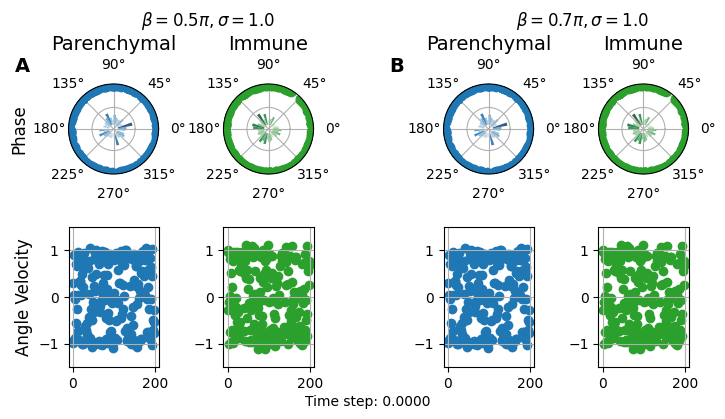

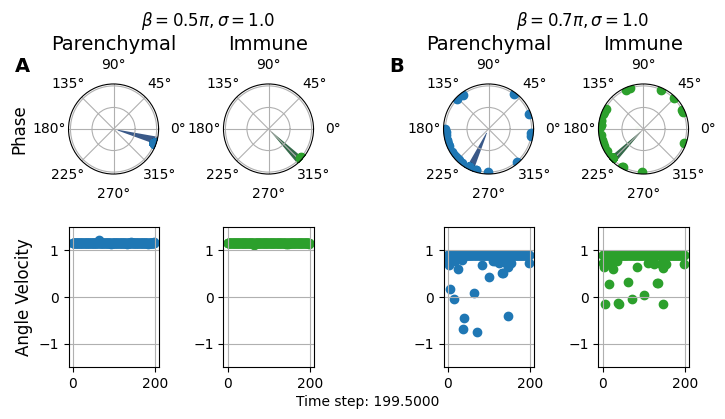

In [26]:
gif_both(
    ys_sync, dys_sync, ys_cluster, dys_cluster,
    ts_sync,
    filename="../typst/images/presentation/simulation0.png",
    single=0,
)
gif_both(
    ys_sync, dys_sync, ys_cluster, dys_cluster,
    ts_sync,
    filename="../typst/images/presentation/simulation1.png",
    single=-1,
)

In [122]:
N = 200
M = 50
run_confs = [conf_sync, conf_cluster]
step_size = 10
T_max = 1000
T_step = 10
dnm = DynamicNetworkModel(full_save=False, steady_state_check=False, progress_bar=True)
ensemble_sols = [
    dnm.integrate(
        config=run_conf,
        M=M,
        key=jr.key(0),
        T_init=T_init,
        T_max=T_max,
        T_step=T_step,
        solver=Dopri5(),
        ts=jnp.arange(T_init, T_max, step_size),
    )
    for run_conf in run_confs
]

100.00%|███████████████████████████████████████████████████████████████████████████████████████| [00:50<00:00,  1.99%/s]
100.00%|███████████████████████████████████████████████████████████████████████████████████████| [00:50<00:00,  1.99%/s]


In [295]:
def plot_ensembles() -> None:
    fig, axs = plt.subplots(len(ensemble_sols), 1, figsize=(6, 5), sharex=True)

    ysmax = 0.0
    for i, sol in enumerate(ensemble_sols):
        t = np.arange(sol.ys.r_1.shape[0]) * T_step
        ysmax = max(sol.ys.s_1.max(), sol.ys.s_2.max(), ysmax)
        ax0 = axs[i]
        ax0.plot(t, sol.ys.s_1, color="tab:blue", alpha=0.8)
        
        ax0.plot((0, 0), (0, 0), label="Single Ensemble Member", color="tab:blue", rasterized=True)
        ax0.plot(t, sol.ys.s_1.mean(axis=-1), c="tab:orange", label="Ensemble Mean")
        ax0.text(-0.16, 0.5, f"{('A', 'B')[i]}",
                 transform=ax0.transAxes, fontsize=14, fontweight='bold', va='top')
        if i>0:
            ax0.set_xlabel("t")
        ax0.set_ylim(0, ysmax * 1.05)
    axs[0].set_title(r"Standard Deviation of the Phase Velocity ($s^1$)" + "\n" + "Parenchymal Layer")
    axs[0].legend(ncols=2, bbox_to_anchor=(1.0, 1.5), frameon=False)
    
    fig.subplots_adjust(wspace=0.4)
    return fig

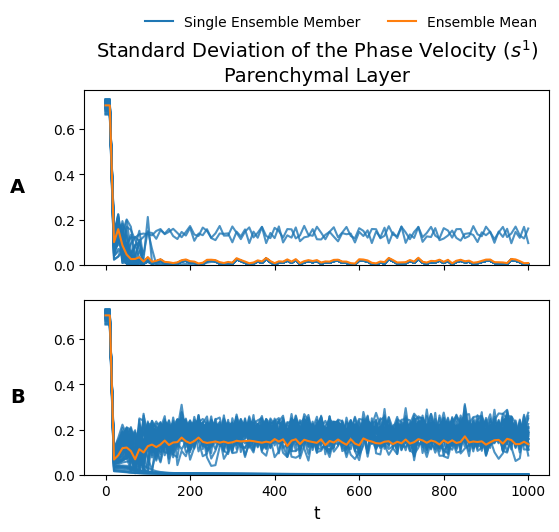

In [296]:
ensemble_fig = plot_ensembles()

In [297]:
ensemble_fig.savefig("../typst/images/presentation/ensembles.svg")

In [189]:
ALPHA = -0.28
BETA_SPACE = (0.4, 0.7, 0.005)  # only original area
SIGMA_SPACE = (0.0, 1.5, 0.015)  # only original area
db_str = "DaisyFinal"
sim_storage = Storage(
    key_dim=9,
    metrics_kv_name=f"../data/{db_str}SepsisMetrics.db/",
    parameter_k_name=f"../data/{db_str}SepsisParameters_index.bin",
    use_mem_cache=True,
)
sim_storage.close()

b, r = as_2d_indices(BETA_SPACE, SIGMA_SPACE)
a = np.ones_like(b) * ALPHA
indices_3d = jnp.concatenate([a[..., np.newaxis], b[..., np.newaxis], r[..., np.newaxis]], axis=-1)[np.newaxis, ...]

spacing_3d = jnp.array([0.0, BETA_SPACE[2], SIGMA_SPACE[2]])
params = DNMConfig.batch_as_index(a, b, r, 0.2)
metrics_3d, _ = sim_storage.read_multiple_results(params, proto_metric=DNMMetrics, threshold=0.0)
metrics_3d = metrics_3d.to_jax().reshape([1, *metrics_3d.shape["r_1"]])
metrics_2d = metrics_3d.squeeze()

2026-02-19 10:15:46 - sepsis_osc.storage.storage_interface - INFO     - Got ../data/DaisyFinalSepsisParameters_index.bin and ../data/DaisyFinalSepsisMetrics.db/
2026-02-19 10:15:46 - sepsis_osc.storage.storage_interface - INFO     - FAISS index ../data/DaisyFinalSepsisParameters_index.bin loaded from disk.
2026-02-19 10:15:46 - sepsis_osc.storage.storage_interface - INFO     - Preloading memory cache from RocksDB...
2026-02-19 10:15:47 - sepsis_osc.storage.storage_interface - INFO     - Successfully loaded 76000 metrics into memory.
2026-02-19 10:15:47 - sepsis_osc.utils.utils         - INFO     - func:'__setup_memory_cache' took: 1.673617 sec
2026-02-19 10:15:48 - sepsis_osc.storage.storage_interface - INFO     - Getting Metrics for multiple queries with shape (60, 100, 9)
2026-02-19 10:15:48 - sepsis_osc.storage.storage_interface - INFO     - Searching 6000 keys in FAISS index
2026-02-19 10:15:48 - sepsis_osc.storage.storage_interface - INFO     - Found vectors with distance 0.0, ind

In [289]:
def plot_phase() -> plt.Figure:
    xs = np.arange(*BETA_SPACE)
    ys = np.arange(*SIGMA_SPACE)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    space_plot(
        metrics_2d.s_1, title=r"Standard Deviation of the Phase Velocity ($s^1$)" + "\n" + "Parenchymal Layer", xs=xs, ys=ys, figax=(fig, ax),
    )

    configs = {"A": (0.5, 1.0), "B": (0.697, 1.0)}
    for n, c in configs.items():
        b, s = c
        beta_scale = len(xs) * (b - BETA_SPACE[0]) / (BETA_SPACE[1] - BETA_SPACE[0])
        sigma_scale = len(ys) * (1 - (s - SIGMA_SPACE[0]) / (SIGMA_SPACE[1] - SIGMA_SPACE[0]))
        ax.scatter(beta_scale, sigma_scale, c="tab:orange")
        ax.annotate(n, (beta_scale -5, sigma_scale + 1), c="tab:orange", fontsize=18)

    fig.tight_layout()
    fig.subplots_adjust(wspace=0., hspace=0.25)
    return fig

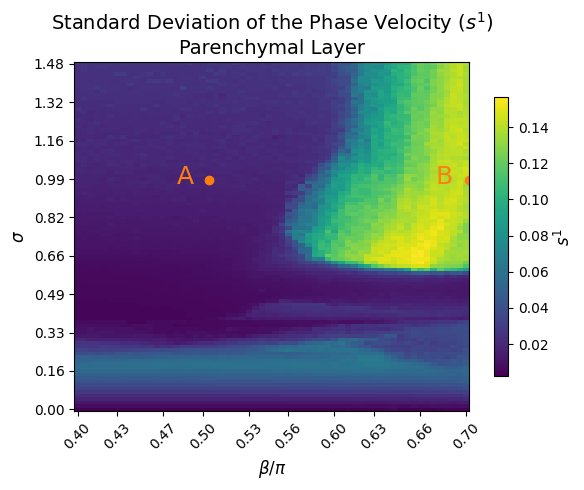

In [290]:
phase_fig = plot_phase()

In [291]:
phase_fig.savefig("../typst/images/presentation/phase.svg")

# LDM

In [53]:
from tbparse import SummaryReader
import equinox as eqx
from matplotlib.pyplot import Figure, Axes
from matplotlib import colors
from matplotlib.gridspec import GridSpec
from sklearn.metrics import average_precision_score, roc_auc_score

from sepsis_osc.ldm.train_online import process_val_epoch
from sepsis_osc.ldm.checkpoint_utils import load_checkpoint
from sepsis_osc.ldm.commons import build_lookup_table
from sepsis_osc.ldm.data_loading import get_data_sets_online, prepare_batches_mask
from sepsis_osc.ldm.model_structs import LossesConfig, LoadingConfig
from sepsis_osc.utils.config import ALPHA, BETA_SPACE, SIGMA_SPACE
from sepsis_osc.visualisations.viz_model_results import viz_heatmap_concepts, viz_plane

from scipy.stats import binned_statistic_2d

setup_jax(simulation=False)

In [3]:
(
    train_x,
    train_y,
    train_m,
    val_x,
    val_y,
    val_m,
    test_x,
    test_y,
    test_m,
) = get_data_sets_online(swapaxes_y=(1, 2, 0), dtype=jnp.float32, path_prefix="..", cv_repetitions=2, repetition_index=0, cv_folds=2, fold_index=0)
for y, m, s in ((train_y, train_m, "Train"), (val_y, val_m, "Val"), (test_y, test_m, "Test")):
    print(f"Prevalence {s} Set {((y * m[..., None]).max(axis=1) == 1.0).mean(axis=0) * 100}%")
    
key = jr.PRNGKey(jax_random_seed)
test_x, test_y, test_m, _ = prepare_batches_mask(test_x, test_y, test_m, test_x.shape[0], key=key)
test_x, test_y, test_m = test_x[0], test_y[0], test_m[0]  # strip mini-epoch dimension

loss_conf = LossesConfig(
    lambda_sep3=300.0,
    lambda_inf=1.0,
    lambda_sofa_classification=2000.0,
    lambda_spreading=6e-3,
    lambda_boundary=30.0,
    lambda_recon=2.5,
)
db_str = "DaisyFinal"
storage = Storage(
    key_dim=9,
    metrics_kv_name=f"../data/{db_str}SepsisMetrics.db/",
    parameter_k_name=f"../data/{db_str}SepsisParameters_index.bin",
    use_mem_cache=True,
)
storage.close()
lookup_table = build_lookup_table(storage, alpha=ALPHA, beta_space=BETA_SPACE, sigma_space=SIGMA_SPACE)

2026-02-24 20:17:45 - sepsis_osc.ldm.data_loading    - INFO     - Processed sequence files found. Loading data from disk...
2026-02-24 20:17:47 - sepsis_osc.ldm.data_loading    - INFO     - Data loaded successfully.


Prevalence Train Set [13.18486401  7.84391013  5.29365392]%
Prevalence Val Set [13.66861107  8.05612486  5.02916601]%
Prevalence Test Set [13.15042573  8.04162725  4.96688742]%


2026-02-24 20:17:49 - sepsis_osc.storage.storage_interface - INFO     - Got ../data/DaisyFinalSepsisParameters_index.bin and ../data/DaisyFinalSepsisMetrics.db/
2026-02-24 20:17:49 - sepsis_osc.storage.storage_interface - INFO     - FAISS index ../data/DaisyFinalSepsisParameters_index.bin loaded from disk.
2026-02-24 20:17:49 - sepsis_osc.storage.storage_interface - INFO     - Preloading memory cache from RocksDB...
2026-02-24 20:17:50 - sepsis_osc.storage.storage_interface - INFO     - Successfully loaded 76000 metrics into memory.
2026-02-24 20:17:50 - sepsis_osc.utils.utils         - INFO     - func:'__setup_memory_cache' took: 1.522924 sec
2026-02-24 20:17:50 - sepsis_osc.storage.storage_interface - INFO     - Getting Metrics for multiple queries with shape (60, 100, 9)
2026-02-24 20:17:50 - sepsis_osc.storage.storage_interface - INFO     - Searching 6000 keys in FAISS index
2026-02-24 20:17:51 - sepsis_osc.storage.storage_interface - INFO     - Found vectors with distance 0.0, ind

In [6]:
run_name = "best"
RUN_DIR = f"../runs/{run_name}"
tb_reader = SummaryReader(RUN_DIR)
tb_df = tb_reader.scalars

hparams = tb_reader.hparams.T
hparams.columns = hparams.loc["tag"]
hparams = hparams.drop("tag")

auprc = tb_df.query("tag == 'sepsis_metrics/AUPRC_pred_sep'")
prc_epoch = auprc.loc[auprc["value"].idxmax(), "step"]
auroc = tb_df.query("tag == 'sepsis_metrics/AUROC_pred_sep'")
roc_epoch = auroc.loc[auroc["value"].idxmax(), "step"]
best_epoch = round((prc_epoch + roc_epoch) / 2)
print(
    f"Best Epoch: {best_epoch} with between AUPRC={auprc['value'].max():.3f}@{prc_epoch} AUROC={auroc['value'].max():.3f}@{roc_epoch}"
)
LOAD_EPOCH = best_epoch

key = jr.PRNGKey(jax_random_seed)

load_conf = LoadingConfig(from_dir=RUN_DIR, epoch=LOAD_EPOCH)
if load_conf.from_dir:
    try:
        model, _ = load_checkpoint(load_conf.from_dir + "/checkpoints", load_conf.epoch, None)

    except FileNotFoundError as e:
        logger.warning(f"Error loading checkpoint: {e}.")
        load_conf.epoch = 0
        load_conf.from_dir = ""

model = eqx.nn.inference_mode(model)
assert model

2026-02-24 20:18:21 - sepsis_osc.ldm.checkpoint_utils - INFO     - Model checkpoint loaded for epoch 258 from ../runs/best/checkpoints/checkpoint_epoch_0258.eqx


Best Epoch: 258 with between AUPRC=0.104@260 AUROC=0.847@255


In [13]:
test_metrics = process_val_epoch(
    model,
    x_data=test_x,
    y_data=test_y,
    mask_data=test_m,
    step=jnp.array(1e6, dtype=jnp.int32),
    key=key,
    lookup_func=lookup_table.soft_get_local,
    loss_params=loss_conf,
)

2026-02-24 20:20:06 - sepsis_osc.utils.utils         - INFO     - func:'process_val_epoch' took: 0.130608 sec


In [24]:
true_sofa = np.asarray(test_y[..., 0])[test_m]
true_sofa_d2 = np.concat(
    [np.zeros(test_y.shape[:-2])[..., None], np.asarray(jnp.diff(test_y[..., 0], axis=-1) > 0)], axis=-1
)[test_m]
true_inf = np.asarray(test_y[..., 1])[test_m]
true_sep3 = np.asarray(test_y[..., 2] == 1.0)[test_m]
pred_sep3_risk = np.asarray(test_metrics.sep3_risk)[test_m]
pred_sofa_d2_risk = np.asarray(test_metrics.sofa_d2_risk)[test_m]
pred_susp_inf_p = np.asarray(test_metrics.susp_inf_p)[test_m]
pred_sofa_score = np.asarray(test_metrics.hists_sofa_score)[test_m]

print(f"AUROC sepis-3  {roc_auc_score(true_sep3, pred_sep3_risk) * 100:.3f}")
print(f"AUPRC sepis-3  {average_precision_score(true_sep3, pred_sep3_risk) * 100:.3f}")
print(f"AUROC sofa d2  {roc_auc_score(true_sofa_d2, pred_sofa_d2_risk) * 100:.2f}")
print(f"AUPRC sofa d2  {average_precision_score(true_sofa_d2, pred_sofa_d2_risk) * 100:.2f}")
print(f"AUROC susp inf {roc_auc_score(true_inf > 0, pred_susp_inf_p) * 100:.2f}")
print(f"AUPRC susp inf {average_precision_score(true_inf > 0, pred_susp_inf_p) * 100:.2f}")

AUROC sepis-3  84.690
AUPRC sepis-3  9.982
AUROC sofa d2  61.56
AUPRC sofa d2  7.74
AUROC susp inf 72.54
AUPRC susp inf 20.63


In [88]:
def viz_heatmap_concepts(
    true_sofa: jnp.ndarray | np.ndarray,
    true_infs: jnp.ndarray | np.ndarray,
    pred_sofa: jnp.ndarray | np.ndarray,
    pred_infs: jnp.ndarray | np.ndarray,
    *,
    cmap: bool,
    figax: tuple[Figure, tuple[Axes, Axes, Axes]] | None = None,
) -> tuple[Figure, tuple[Axes, Axes, Axes]]:
    if figax is not None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(1, 3)

    sofa_bins = [np.arange(-0.5, 24.5, 1), np.arange(-0.5, 24.5, 1)]
    sofa_heatmap = np.histogram2d(true_sofa, pred_sofa, bins=sofa_bins)
    sofa = (sofa_heatmap, r"SOFA-score", ax[0])

    dsofa_bins = [np.arange(-24.5, 24.5, 1), np.arange(-24.5, 24.5, 1)]  # 1-point bins
    dsofa_heatmap = np.histogram2d(np.diff(true_sofa), np.diff(pred_sofa), bins=dsofa_bins)
    dsofa = (dsofa_heatmap, r"$\Delta$SOFA-score", ax[1])

    infection_bins = [np.arange(-0.05, 1.05, 0.1), np.arange(-0.05, 1.05, 0.1)]
    inf_heatmap = np.histogram2d(true_infs, pred_infs, bins=infection_bins)
    inf = (inf_heatmap, r"$I_t$", ax[2])
    
    heats = np.log(
        np.concat(
            [
                np.asarray(sofa_heatmap[0]).flatten(),
                np.asarray(dsofa_heatmap[0]).flatten(),
                np.asarray(inf_heatmap[0]).flatten(),
            ]
        )
        + 1
    )
    norm = colors.Normalize(vmin=np.min(heats), vmax=np.max(heats))

    images = []
    for (heatmap, xedges, yedges), name, axi in [sofa, dsofa, inf]:
        # Plot the 2D histogram as an image
        images.append(
            axi.imshow(
                np.log(heatmap.T + 1),  # transpose so it matches axes orientation
                origin="lower",
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                aspect="equal",
                cmap="magma",
                norm=norm,
            )
        )
        axi.set_title(name)
        axi.set_xlabel(f"Ground Truth")
        axi.plot((xedges[0], xedges[-1]), (yedges[0], yedges[-1]), color="red", label="Optimal", linestyle=":")
    if cmap:
        pos = ax[-1].get_position()

        # Create colorbar axes outside the plot
        cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
        fig.colorbar(images[-1], cax=cax, label="log(Count)")

    ax[0].legend( bbox_to_anchor=(3.85, 1.175))
    ax[0].set_ylabel(f"Predicted")
    fig.subplots_adjust(wspace=0.2)
    return fig, ax

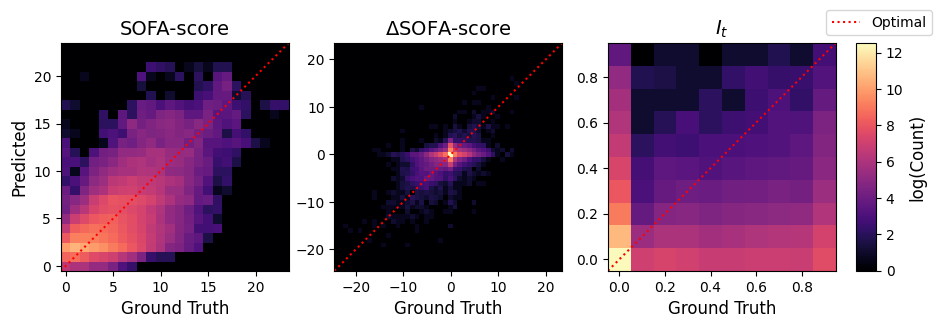

In [89]:
heat_fig, heat_ax = viz_heatmap_concepts(
    true_sofa,
    true_inf,
    pred_sofa_score,
    pred_susp_inf_p,
    cmap=True,
)

In [90]:
heat_fig.savefig("../typst/images/presentation/heat.svg")

In [67]:
def viz_space_heatmap(
    betas: jnp.ndarray,
    sigmas: jnp.ndarray,
    lookup: LatentLookup,
    *,
    mask: np.ndarray,
    cmaps: bool = True,
    figax: tuple[Figure, Axes] | None = None,
) -> tuple[Figure, Axes]:
    if figax is not None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(1, 1)

    fig.subplots_adjust(top=0.95, bottom=0.2)

    betas_space = jnp.arange(*BETA_SPACE)
    sigmas_space = jnp.arange(*SIGMA_SPACE)
    beta_grid, sigma_grid = np.meshgrid(betas_space, sigmas_space, indexing="ij")
    param_grid = np.stack([beta_grid.ravel(), sigma_grid.ravel()], axis=1)
    metrics = lookup.hard_get_fsq(jnp.asarray(param_grid)).reshape(len(betas_space), len(sigmas_space))

    ax = space_plot(
        metrics,
        xs=np.asarray(betas_space),
        ys=np.asarray(sigmas_space),
        title=rf"",
        cmap=True,
        figax=(fig, ax),
        filename="",
    )
    
    N, T = betas.shape
    reso = 0.25
    bins = [np.arange(BETA_SPACE[0], BETA_SPACE[1], BETA_SPACE[2]*reso), 
            np.arange(SIGMA_SPACE[0], SIGMA_SPACE[1], SIGMA_SPACE[2]*reso)]
    heatmap, xedges, yedges = np.histogram2d(betas[mask], sigmas[mask], bins=bins)
    heatmap = heatmap[:, ::-1].T
    
    alpha = np.ones_like(heatmap, dtype=np.float32)
    alpha[heatmap == 0] = 0.0 

    im = ax.images[0]
    extent = im.get_extent()
    
    cbar = ax.images[0].colorbar
    cbar_ax = cbar.ax
    pos = cbar_ax.get_position()
    cbar_ax.set_position([pos.x0-0.03, pos.y0, pos.width, pos.height])

    # scatter
    # Same bins you used for the count heatmap
    x = betas[mask]
    y = sigmas[mask]
    values = test_y[0, mask, 0]  # SOFA score
    
    mean_map, xedges, yedges, _ = binned_statistic_2d(
        x, y, values,
        statistic='mean',
        bins=bins
    )
    
    # Match orientation to your earlier heatmap
    mean_map = mean_map[:, ::-1].T
    alpha_mean = ~np.isnan(mean_map)
    mean_map = np.nan_to_num(mean_map, nan=0.0)
    cm = plt.colormaps.get_cmap("copper")
    norm = colors.Normalize(vmin=0, vmax=24)
    
    im_mean = ax.imshow(
        mean_map,
        extent=extent,
        aspect="auto",
        cmap=cm,
        norm=norm,
        alpha=alpha_mean.astype(float)
    )
    
    cbar = fig.colorbar(im_mean, ax=ax, location="right", shrink=0.8)
    cbar.set_label("Mean of the ground truth SOFA-score")
    ax.set_xlabel(r"$\beta / \pi$")
    ax.set_ylabel(r"$\sigma$")
    #fig.subplots_adjust(hspace=0.2)
    #ax0.text(-0.3, 1.1, 'A', transform=ax0.transAxes, fontsize=14, fontweight='bold', va='top')
    #ax0.text(-0.1, 1.1, 'B', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
    return fig, ax

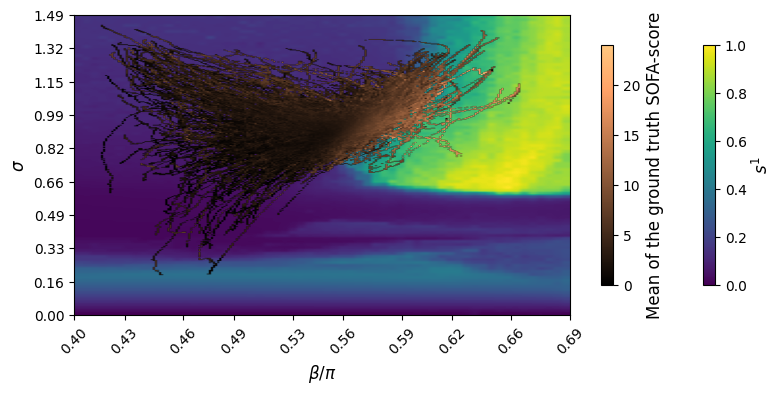

In [68]:
heat_space_fig, ax = viz_space_heatmap(
    test_metrics.beta[0],
    test_metrics.sigma[0],
    lookup=lookup_table,
    mask=test_m[0],
)

In [69]:
heat_space_fig.savefig("../typst/images/presentation/heat_space.svg")